In [2]:
#--- Importing all Libraries------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
#---- loading all 4 datasets-------
orders   = pd.read_csv(r'C:\Users\hemas\OneDrive\Desktop\ecommerce-rfm-project\data\olist_orders_dataset.csv')
items    = pd.read_csv(r'C:\Users\hemas\OneDrive\Desktop\ecommerce-rfm-project\data\olist_order_items_dataset.csv')
customers= pd.read_csv(r'C:\Users\hemas\OneDrive\Desktop\ecommerce-rfm-project\data\olist_customers_dataset.csv')
products = pd.read_csv(r'C:\Users\hemas\OneDrive\Desktop\ecommerce-rfm-project\data\olist_products_dataset.csv')

print(f"orders         : {orders.shape}")
print(f"items          : {items.shape}")
print(f"customers      : {customers.shape}")
print(f"products       : {products.shape}")


orders         : (99441, 8)
items          : (112650, 7)
customers      : (99441, 5)
products       : (32951, 9)


In [4]:
#---- Quick look at the orders table ---
print("ORDERS TABLE")
print(orders.head(3))
print("\nColumn names:",orders.columns.tolist())
print("\nNUll values:\n", orders.isnull().sum())

ORDERS TABLE
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08-07 15:27:45   
2          2018-08-08 13:50:00           2018-08-17 18:06:29   

  order_estimated_delivery_date  
0           2017-10-18 00:00:00  
1           2018-08-13 00:00:00  
2           2018-09-04 00:00:00  

Column names: ['order_id', 'customer_id', '

In [5]:
#--- step1: fix data columns---
orders['order_purchase_timestamp']=pd.to_datetime(orders['order_purchase_timestamp'],errors='coerce')

#--step2: keep only delivered orders---
orders = orders[orders['order_status'] == 'delivered'].copy()
print(f"Delivered orders : {len(orders):,}")

#-- step3: Merge all 4 tables---
df = orders.merge(items,     on='order_id',     how='inner')
df = df.merge(customers,     on='customer_id',  how='inner')
df = df.merge(products,      on='product_id',   how='left')

#--step4: Remove nulls ---
before = len(df)
df.dropna(subset=['order_purchase_timestamp','price','customer_unique_id'],inplace=True)
print(f"Rows before cleaning   : {before:,}")
print(f"Rows after cleaning    : {len(df):,}")

#step5: Create  new useful columns--
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')
df['order_year']  = df['order_purchase_timestamp'].dt.year
df['total_price'] = df['price'] + df['freight_value'].fillna(0)

print(f"\n✅ Master table ready!")
print(f"shape : {df.shape}")

Delivered orders : 96,478
Rows before cleaning   : 110,197
Rows after cleaning    : 110,197

✅ Master table ready!
shape : (110197, 29)


✅ chart saved to charts folder!


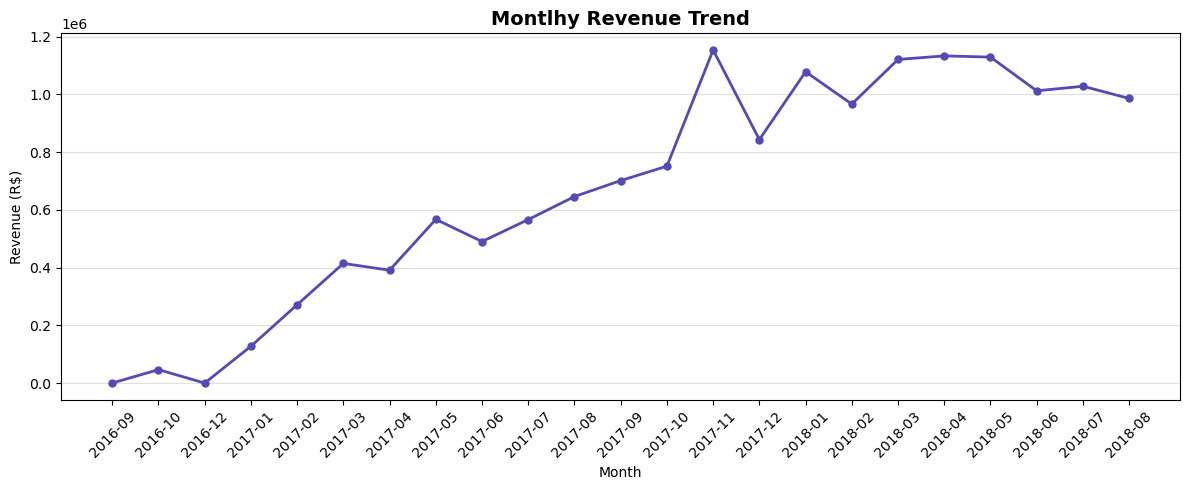

In [6]:
#--- monthly Revenue Trend----
monthly_rev = ( 
    df.groupby('order_month')['total_price']
     .sum()
    .reset_index()
)
monthly_rev['order_month']=monthly_rev['order_month'].astype(str)

plt.figure(figsize=(12,5))
plt.plot(monthly_rev['order_month'],
        monthly_rev['total_price'],
        marker='o',linewidth=2,
        color='#534AB7',markersize=5)

plt.title('Montlhy Revenue Trend',fontsize=14,fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (R$)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig(r'C:\Users\hemas\OneDrive\Desktop\ecommerce-rfm-project\charts/Monthly_revenue.png',dpi=150)

print("✅ chart saved to charts folder!")

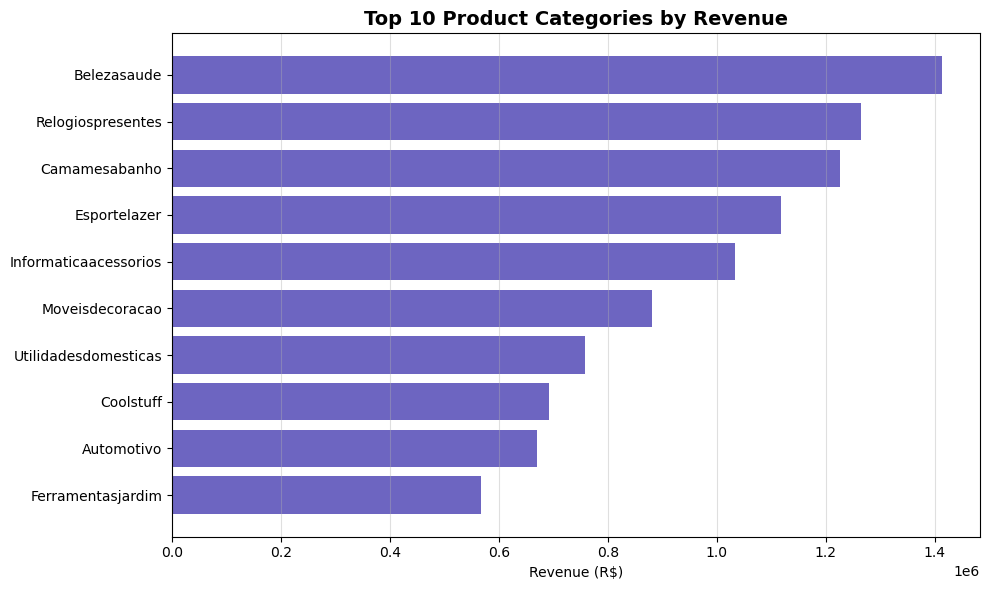

✅ Chart saved to charts folder!


In [8]:
# -- Top 10 Product Categories by Revenue ---
top_cats=(
    df.groupby('product_category_name')['total_price']
    .sum()
    .nlargest(10)
    .reset_index()
)
top_cats.columns=['category','revenue']
top_cats['category']=(top_cats['category']
                      .str.replace('_','')
                      .str.title())
plt.figure(figsize=(10,6))
bars = plt.barh(top_cats['category'],
                top_cats['revenue'],
                color='#534AB7', alpha=0.85)

plt.title('Top 10 Product Categories by Revenue',
          fontsize=14,fontweight='bold')
plt.xlabel('Revenue (R$)')
plt.gca().invert_yaxis()
plt.grid(axis='x',alpha=0.4)
plt.tight_layout()
plt.savefig(r'C:\Users\hemas\OneDrive\Desktop\ecommerce-rfm-project\charts\top_categories.png',dpi=150)
plt.show()

print("✅ Chart saved to charts folder!")


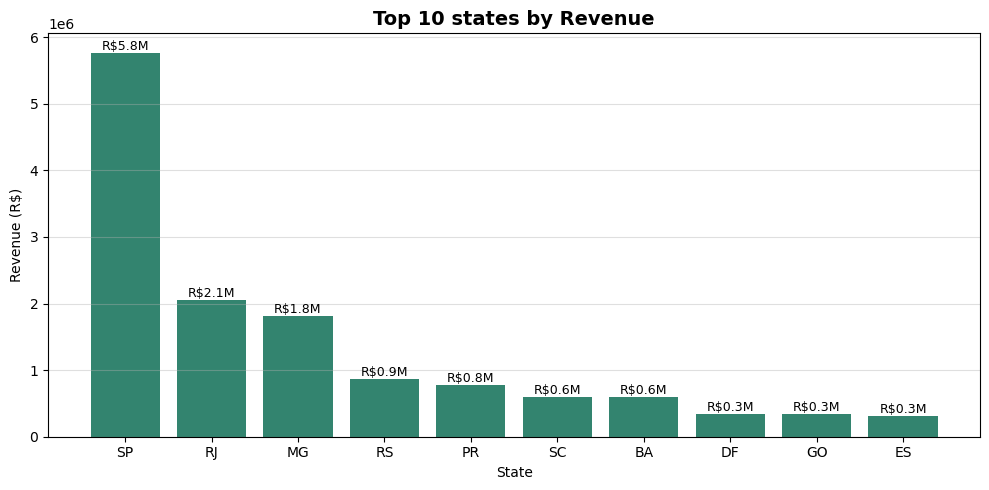

✅ Chart saved to charts folder!


In [11]:
# --- Revenue  by state (Top 10)---
top_states=(
    df.groupby('customer_state')['total_price']
    .sum()
    .nlargest(10)
    .reset_index()
)
top_states.columns=['state', 'revenue']

plt.figure(figsize=(10,5))
bars = plt.bar(top_states['state'],
               top_states['revenue'],
               color='#0F6E56', alpha=0.85)

plt.title('Top 10 states by Revenue',
          fontsize=14,fontweight='bold')
plt.xlabel('State')
plt.ylabel('Revenue (R$)')
plt.grid(axis='y', alpha=0.4)

#---And value labels on the top of each bar---
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x()+ bar.get_width()/2.,
            height,
            f'R${height/1e6:.1f}M',
            ha='center', va='bottom',
            fontsize=9)

plt.tight_layout()
plt.savefig(r'C:\Users\hemas\OneDrive\Desktop\ecommerce-rfm-project\charts\revenue_by_state.png',dpi=150) 
plt.show()

print("✅ Chart saved to charts folder!")

In [13]:
#---- RFM Calculation ---
# Snapshot date =1 day after the last order 
snapshot_date= df['order_purchase_timestamp'].max()+ pd.Timedelta(days=1)
print(f"Sanpshot date : {snapshot_date.date()}")

#Calculate  R , F , M for each customer
rfm =df.groupby('customer_unique_id').agg(
    Recency  = ('order_purchase_timestamp',
                lambda x:(snapshot_date - x.max()).days),
    Frequency  = ('order_id', 'nunique'),
    Monetary  = ('total_price','sum')
).reset_index()

print(f"\nTotal unique customers : {len(rfm):,}")
print("\nRFM table sample:")
print(rfm.head())
print("\nRFM statistics")
print(rfm[['Recency','Frequency','Monetary']].describe().round(1))


Sanpshot date : 2018-08-30

Total unique customers : 93,358

RFM table sample:
                 customer_unique_id  Recency  Frequency  Monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19
2  0000f46a3911fa3c0805444483337064      537          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89

RFM statistics
       Recency  Frequency  Monetary
count  93358.0    93358.0   93358.0
mean     237.9        1.0     165.2
std      152.6        0.2     226.3
min        1.0        1.0       9.6
25%      114.0        1.0      63.0
50%      219.0        1.0     107.8
75%      346.0        1.0     182.5
max      714.0       15.0   13664.1


In [19]:
# -- RFM Scoring--
# R score - lower recency = better = higher score
rfm['R_score']= pd.qcut(rfm['Recency'],
                        q=4,
                        labels=[4,3,2,1],
                        duplicates='drop')
#F score - higher frequency = better = higher score 
rfm['F_score']= pd.qcut(rfm['Frequency'].rank(method='first'),
                       q=4,
                       labels=[1,2,3,4])

#M score -higher monetary = better = higher score 
rfm['M_score']=pd.qcut(rfm['Monetary'],
                       q=4,
                       labels=[1,2,3,4],
                       duplicates='drop')

#convert to integer
rfm['R_score']=rfm['R_score'].astype(int)
rfm['F_score']=rfm['F_score'].astype(int)
rfm['M_score']=rfm['M_score'].astype(int)

#Total RFM integer
rfm['RFM_Total']=rfm['R_score']+rfm['F_score']+rfm['M_score']

print("✅ Scoring done!")
print("\nSample with scores:")
print(rfm[['customer_unique_id','Recency','Frequency','Monetary','R_score','F_score','M_score','RFM_Total']].head())

✅ Scoring done!

Sample with scores:
                 customer_unique_id  Recency  Frequency  Monetary  R_score  \
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90        4   
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19        3   
2  0000f46a3911fa3c0805444483337064      537          1     86.22        1   
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62        2   
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89        2   

   F_score  M_score  RFM_Total  
0        1        3          8  
1        1        1          5  
2        1        2          4  
3        1        1          4  
4        1        4          7  


In [20]:
# ── Customer Segmentation ──

def assign_segment(row):
    r = row['R_score']
    f = row['F_score']
    m = row['M_score']
    total = row['RFM_Total']

    if r >= 3 and f >= 3 and m >= 3:
        return 'Champion'
    elif r >= 3 and f >= 2:
        return 'Loyal Customer'
    elif r >= 3 and f == 1:
        return 'New Customer'
    elif r == 2 and total >= 7:
        return 'Potential Loyalist'
    elif r == 2 and total < 7:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

# ── Summary table ──
seg_summary = rfm.groupby('Segment').agg(
    Customer_Count = ('customer_unique_id', 'count'),
    Avg_Recency    = ('Recency',    'mean'),
    Avg_Frequency  = ('Frequency',  'mean'),
    Avg_Monetary   = ('Monetary',   'mean'),
    Total_Revenue  = ('Monetary',   'sum')
).round(1).reset_index()

seg_summary = seg_summary.sort_values('Customer_Count', 
                                       ascending=False)

print("✅ Segmentation done!")
print("\nSegment Summary:")
print(seg_summary.to_string(index=False))

✅ Segmentation done!

Segment Summary:
           Segment  Customer_Count  Avg_Recency  Avg_Frequency  Avg_Monetary  Total_Revenue
              Lost           23311        451.5            1.0         164.2      3827408.0
    Loyal Customer           22878        111.6            1.0         113.4      2593796.7
Potential Loyalist           14395        277.6            1.1         218.0      3137622.3
          Champion           12292        112.6            1.1         271.8      3340718.3
      New Customer           11677        112.7            1.0         160.5      1874704.5
           At Risk            8805        277.1            1.0          73.3       645523.9


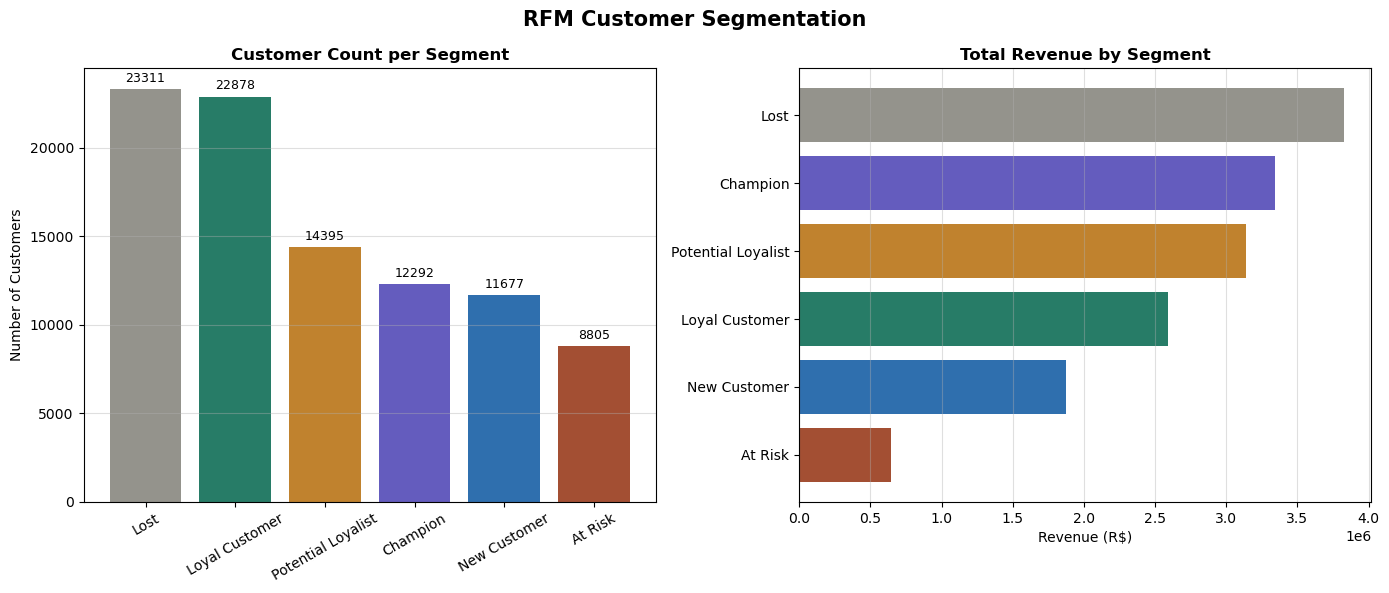

✅ Chart saved to charts folder!


In [21]:
# ── Segment Visualisations ──

COLORS = {
    'Champion':          '#534AB7',
    'Loyal Customer':    '#0F6E56',
    'New Customer':      '#185FA5',
    'Potential Loyalist':'#BA7517',
    'At Risk':           '#993C1D',
    'Lost':              '#888780',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('RFM Customer Segmentation', 
             fontsize=15, fontweight='bold')

# ── Chart 1: Customer count per segment ──
seg_counts = rfm['Segment'].value_counts().reset_index()
seg_counts.columns = ['Segment', 'Count']
colors_list = [COLORS.get(s, '#888780') for s in seg_counts['Segment']]

bars = axes[0].bar(seg_counts['Segment'], 
                   seg_counts['Count'],
                   color=colors_list, alpha=0.9)
axes[0].set_title('Customer Count per Segment', fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=30)
axes[0].bar_label(bars, fmt='%d', padding=3, fontsize=9)
axes[0].grid(axis='y', alpha=0.4)

# ── Chart 2: Revenue per segment ──
seg_rev = rfm.groupby('Segment')['Monetary'].sum().reset_index()
seg_rev = seg_rev.sort_values('Monetary', ascending=True)
seg_colors = [COLORS.get(s, '#888780') for s in seg_rev['Segment']]

axes[1].barh(seg_rev['Segment'], 
             seg_rev['Monetary'],
             color=seg_colors, alpha=0.9)
axes[1].set_title('Total Revenue by Segment', fontweight='bold')
axes[1].set_xlabel('Revenue (R$)')
axes[1].grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig('../charts/rfm_segments.png', dpi=150)
plt.show()

print("✅ Chart saved to charts folder!")

In [22]:
# ── Export to Excel ──

output_path = '../outputs/ecommerce_dashboard_data.xlsx'

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    
    # Sheet 1 — Master cleaned data
    df.to_excel(writer, 
                sheet_name='Master_Data', 
                index=False)
    print("✅ Sheet 1 saved : Master_Data")
    
    # Sheet 2 — RFM scores and segments
    rfm.to_excel(writer, 
                 sheet_name='RFM_Segments', 
                 index=False)
    print("✅ Sheet 2 saved : RFM_Segments")
    
    # Sheet 3 — Segment summary
    seg_summary.to_excel(writer, 
                         sheet_name='Segment_Summary', 
                         index=False)
    print("✅ Sheet 3 saved : Segment_Summary")
    
    # Sheet 4 — Top categories
    top_cats.to_excel(writer, 
                      sheet_name='Top_Categories', 
                      index=False)
    print("✅ Sheet 4 saved : Top_Categories")
    
    # Sheet 5 — Revenue by state
    top_states.to_excel(writer, 
                        sheet_name='Revenue_By_State', 
                        index=False)
    print("✅ Sheet 5 saved : Revenue_By_State")

print(f"\n🎉 Excel file saved to outputs folder!")

✅ Sheet 1 saved : Master_Data
✅ Sheet 2 saved : RFM_Segments
✅ Sheet 3 saved : Segment_Summary
✅ Sheet 4 saved : Top_Categories
✅ Sheet 5 saved : Revenue_By_State

🎉 Excel file saved to outputs folder!
